# Libraries

In [1]:
import joblib
import torch
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [2]:
cleveland = pd.read_csv("data/processed/cleveland_clean.csv")
hungarian = pd.read_csv("data/processed/hungarian_clean.csv")
switzerland = pd.read_csv("data/processed/switzerland_clean.csv")
va = pd.read_csv("data/processed/va_clean.csv")

df = pd.concat(
    [cleveland, hungarian, switzerland, va],
    ignore_index=True
)

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [3]:
X = df.drop("target", axis=1)
y = df["target"]
X_train, X_test_raw, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test_raw)


In [4]:
xgb_model = joblib.load(
    "models/xgboost.pkl"
)

In [5]:
y_pred = xgb_model.predict(X_test_raw)
y_prob = xgb_model.predict_proba(X_test_raw)[:, 1]


In [6]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_prob)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("ROC AUC  :", roc)

Accuracy : 0.8478260869565217
Precision: 0.8854166666666666
Recall   : 0.8333333333333334
F1 Score : 0.8585858585858586
ROC AUC  : 0.9283835485413678


In [7]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.81      0.87      0.84        82
           1       0.89      0.83      0.86       102

    accuracy                           0.85       184
   macro avg       0.85      0.85      0.85       184
weighted avg       0.85      0.85      0.85       184



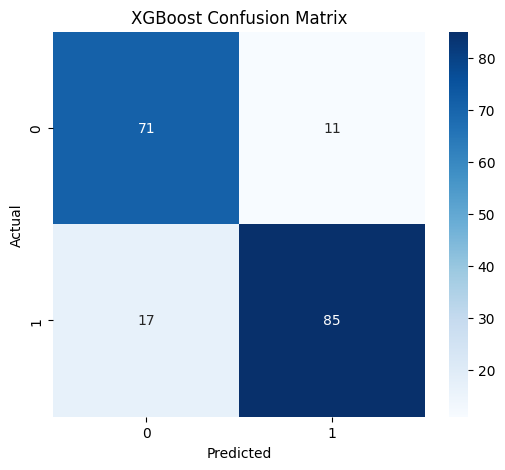

In [8]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("results/confusion_matrix.png")
plt.show()

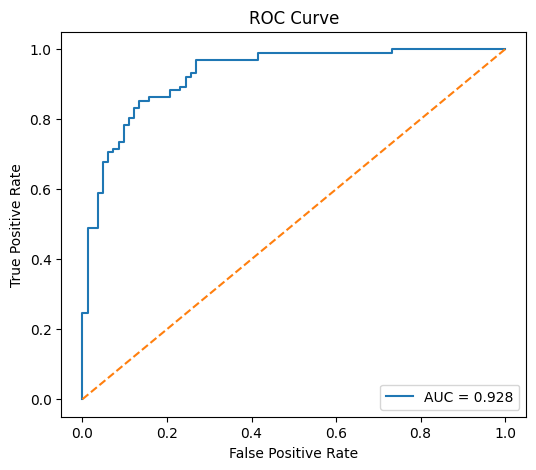

In [9]:
fpr, tpr, _ = roc_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(6,5))
plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    "--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.savefig(
    "results/roc_curve.png"
)
plt.show()

In [10]:
class HeartDiseaseNet(torch.nn.Module):
    def __init__(self, num_features):
        super().__init__()
        self.network = torch.nn.Sequential(
            torch.nn.Linear(num_features, 32),
            torch.nn.ReLU(),
            torch.nn.Dropout(0.20),
            torch.nn.Linear(32, 16),
            torch.nn.ReLU(),
            torch.nn.Linear(16, 1),
        )

    def forward(self, x):
        return self.network(x)


In [11]:
fl_checkpoint = torch.load(
    "models/global_model.pth",
    map_location="cpu",
    weights_only=False
)

feature_columns = fl_checkpoint.get("feature_columns", list(X.columns))
X_test_fl = X_test_raw[feature_columns].to_numpy(dtype=np.float32)

if "scaler_mean" in fl_checkpoint and "scaler_scale" in fl_checkpoint:
    X_test_fl = (X_test_fl - fl_checkpoint["scaler_mean"]) / fl_checkpoint["scaler_scale"]

fl_model = HeartDiseaseNet(len(feature_columns))
fl_model.load_state_dict(fl_checkpoint["model_state_dict"])
fl_model.eval()


HeartDiseaseNet(
  (network): Sequential(
    (0): Linear(in_features=13, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=32, out_features=16, bias=True)
    (4): ReLU()
    (5): Linear(in_features=16, out_features=1, bias=True)
  )
)

In [12]:
X_tensor = torch.tensor(
    X_test_fl,
    dtype=torch.float32
)

with torch.no_grad():
    pred = torch.sigmoid(fl_model(X_tensor)).numpy().ravel()

pred_class = (pred >= 0.5).astype(int)

fl_accuracy = accuracy_score(
    y_test,
    pred_class
)

print(fl_accuracy)


0.8315217391304348


In [13]:
centralized_results = pd.read_csv("results/centralized_results.csv")
dp_results = pd.read_csv("results/dp_federated_results.csv")

def test_accuracy(model_name):
    row = centralized_results.loc[centralized_results["Model"] == model_name, "Accuracy"]
    if row.empty:
        raise ValueError(f"Missing accuracy for {model_name}")
    return float(row.iloc[0])

dp_accuracy = float(dp_results.loc[0, "accuracy"])

comparison = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Random Forest",
        "XGBoost",
        "Federated Learning",
        "Federated + DP"
    ],

    "Accuracy":[
        test_accuracy("Logistic Regression (Test)"),
        test_accuracy("Random Forest (Test)"),
        test_accuracy("XGBoost (Test)"),
        fl_accuracy,
        dp_accuracy
    ]

})

comparison


,Model,Accuracy
0,Logistic Regression,0.842391
1,Random Forest,0.826087
2,XGBoost,0.847826
3,Federated Learning,0.831522
4,Federated + DP,0.821622


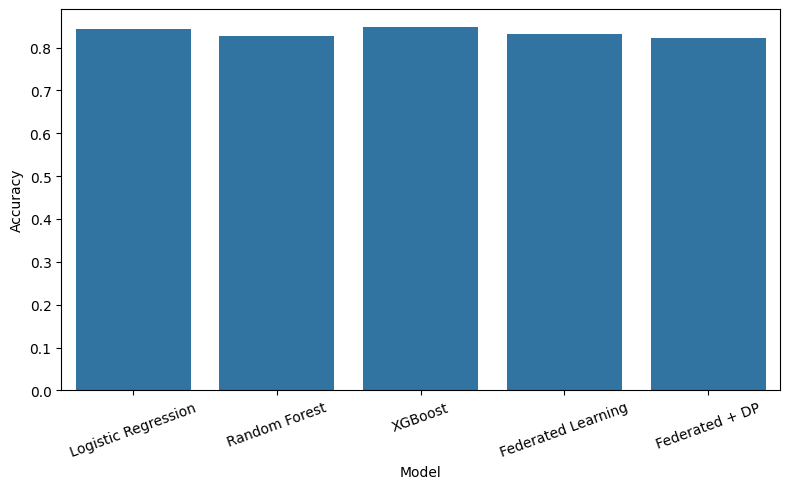

In [14]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=comparison,
    x="Model",
    y="Accuracy"
)

plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(
    "results/model_comparison.png"
)

plt.show()

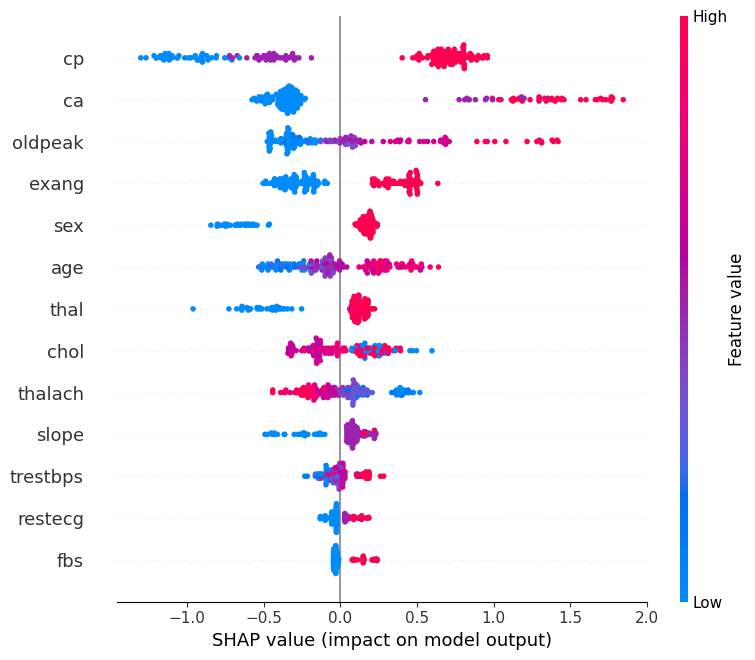

In [15]:
import shap

if hasattr(xgb_model, "named_steps") and "model" in xgb_model.named_steps:
    xgb_estimator = xgb_model.named_steps["model"]
    xgb_preprocessor = xgb_model[:-1]
    shap_input = xgb_preprocessor.transform(X_test_raw)
else:
    xgb_estimator = xgb_model
    shap_input = X_test_raw

explainer = shap.TreeExplainer(xgb_estimator)
shap_values = explainer.shap_values(shap_input)

shap.summary_plot(
    shap_values,
    shap_input,
    feature_names=X.columns,
    show=False
)

plt.savefig(
    "results/shap_summary.png",
    bbox_inches="tight"
)
plt.show()
